![display relevant image here](path/url/to/image)
- Banner/header image

# Title
FinTech Innovations — Loan Approval Risk Model


## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

A Gradient Boosting model predicts loan approval with strong accuracy and ROC-AUC, with `TotalDebtToIncomeRatio` and `AnnualIncome` as the biggest drivers of the decision. Used as a decision-support tool for underwriters, this could make approvals faster and more consistent than manual review, while the custom cost metric gives FinTech a dollar-based way to judge whether a model is actually worth deploying — not just whether it's "accurate.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


Currently at FinTech, our loan approval process relies entirely on manual underwriting. As application volumes scale, this approach has become a bottleneck—it is too slow and leads to inconsistent decisions across different loan officers. To solve this, we want to introduce an automated decisioning tool. However, this cannot be a "black box." Our core stakeholders have very specific requirements:Underwriters need a transparent system with clear, explainable logic so they can trust and understand the recommendations.Risk & Compliance must be able to audit every decision to ensure full adherence to fair-lending regulations.Finance focuses on the bottom line, balancing default losses against missed revenue opportunities.Asymmetric Error Costs & Metric ChoiceIn credit risk, mistakes are not created equal. A false approval (approving a borrower who defaults) is significantly more expensive than a false rejection (turning away a creditworthy applicant and losing their interest revenue).Because the financial stakes are uneven and our dataset has a natural class imbalance ($76\%$ approved vs. $24\%$ rejected), traditional accuracy is a misleading metric. Instead, we will evaluate our models using Precision, Recall, F1-score, and ROC-AUC. Crucially, we will also implement a custom, cost-weighted metric to translate these classification errors directly into financial dollars, aligning the data science with business realities.Framing the Machine Learning ProblemWhile the dataset provides two potential targets—LoanApproved (binary) and RiskScore (continuous)—this project focuses strictly on binary classification using LoanApproved. This directly mirrors the immediate, operational decision the business needs to make today. We will flag the continuous RiskScore as a future phase-two regression target for risk-based interest pricing.

**Baseline performance target:** a naive always-reject classifier would score 76% accuracy but 0% recall on approvable loans - that's the floor to beat. Success criteria: substantially exceed this on F1 and ROC-AUC, since accuracy alone is not meaningful given the class imbalance.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                              recall_score, precision_score, confusion_matrix, accuracy_score)

In [2]:
# EDA Code Here - Create New Cells As Needed
#Load dataset
#display the first rows
df = pd.read_csv('financial_loan_data.csv')
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
#No of columns and rows
df.shape


(20000, 35)

In [4]:
#Data structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [5]:
#change AnnualIncome to float
df['AnnualIncome'] = df['AnnualIncome'].replace(r'[\$,]', '', regex=True).astype(float)

In [6]:
#check for missing values
df.isnull().sum()


Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

The dataset had missing values in EducationLevel (901 ), MaritalStatus (1331 ), and SavingsAccountBalance (572 ). Since EducationLevel and MaritalStatus are categorical variables, missing values were replaced using the most frequent category (mode). SavingsAccountBalance , a numerical variable, we used median value to replace the missing values hence reducing the influence of outliers.

**Notable missing-value pattern:** every single applicant missing `EducationLevel` (901 of them) was rejected - a 100% rejection rate, versus ~25% for applicants with `EducationLevel` recorded. This is unlikely to be random (MCAR); it more likely reflects an upstream process artifact, e.g. applications rejected early in manual review before education was ever collected or verified. This is treated as a data quality finding worth raising with FinTech's operations team, not just something to impute away silently.

<Axes: xlabel='LoanApproved', ylabel='count'>

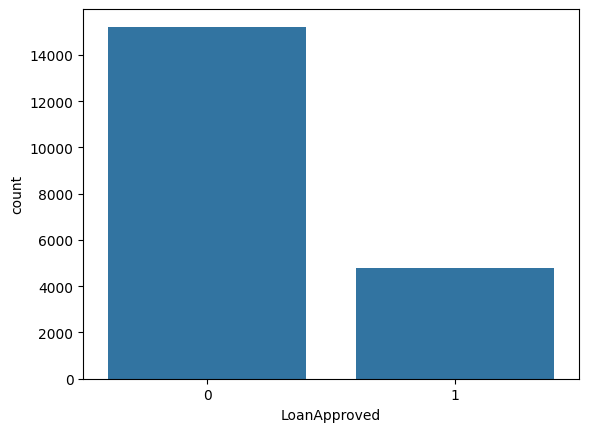

In [7]:
#Distribution of Loan Approval Outcomes
import seaborn as sns

sns.countplot(x='LoanApproved', data=df)

The graph shows that the dataset contains significantly more denied loans  than approved loans . This indicates that the target variable is imbalanced, with loan denials representing the majority class. Such imbalance may influence model performance, making it important to use appropriate evaluation metrics such as ROC-AUC, precision, recall, and the confusion matrix rather than relying solely on accuracy.

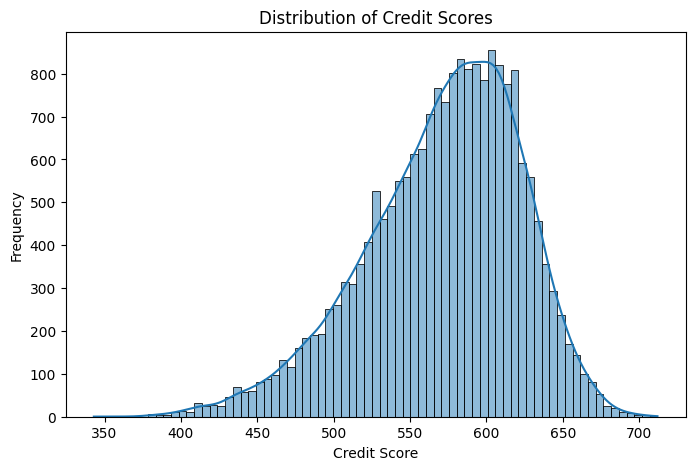

In [8]:
#Distribution of Credit scores
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], kde=True)

plt.title('Distribution of Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

plt.show()

The distribution of credit scores appears approximately bell-shaped, with most applicants having credit scores between 550 and 650. The highest concentration of applicants is around a credit score of 600. Very low and very high credit scores are less common, indicating that most applicants have moderate levels of creditworthiness.

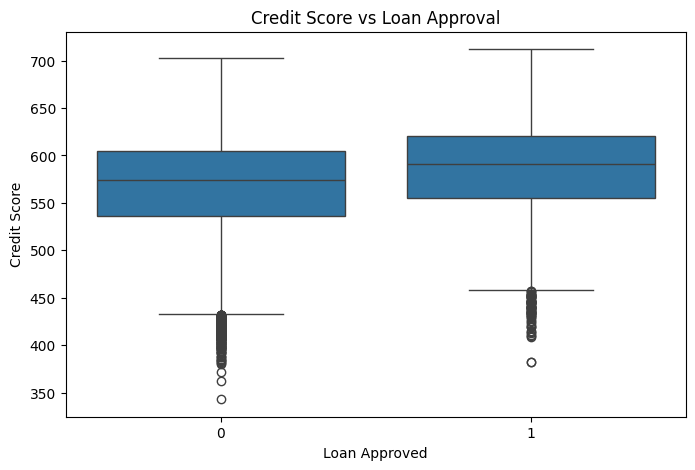

In [9]:
#Credit Score and Loan Approval
plt.figure(figsize=(8,5))

sns.boxplot(
    x='LoanApproved',
    y='CreditScore',
    data=df
)

plt.title('Credit Score vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Credit Score')

plt.show()

The boxplot shows that applicants whose loans were approved (1) generally have slightly higher credit scores than those whose loans were denied (0). The median credit score for approved applicants is higher, suggesting that creditworthiness plays an important role in loan approval decisions. Although there is overlap between the two groups, higher credit scores appear to increase the likelihood of loan approval.

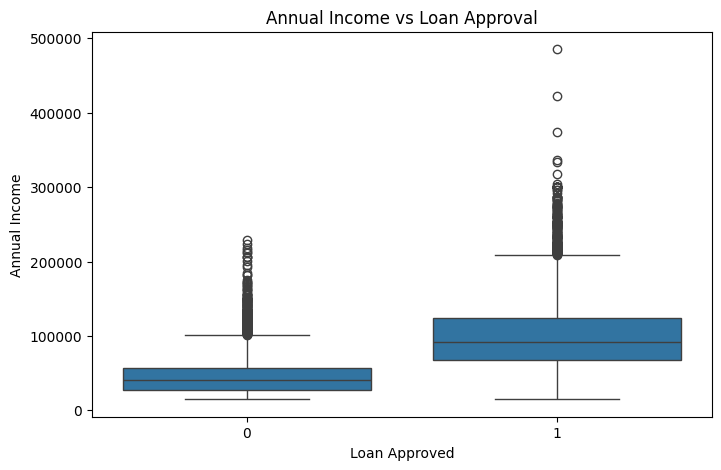

In [10]:
#Annual Income vs Loan Approval
plt.figure(figsize=(8,5))

sns.boxplot(
    x='LoanApproved',
    y='AnnualIncome',
    data=df
)

plt.title('Annual Income vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Annual Income')

plt.show()

The boxplot shows a clear difference in annual income between approved and denied loan applicants. Applicants whose loans were approved (1) generally have significantly higher annual incomes than those whose loans were denied (0). The higher median income among approved applicants suggests that income is an important factor in loan approval decisions, as higher-income individuals may be viewed as having a greater ability to repay loans.

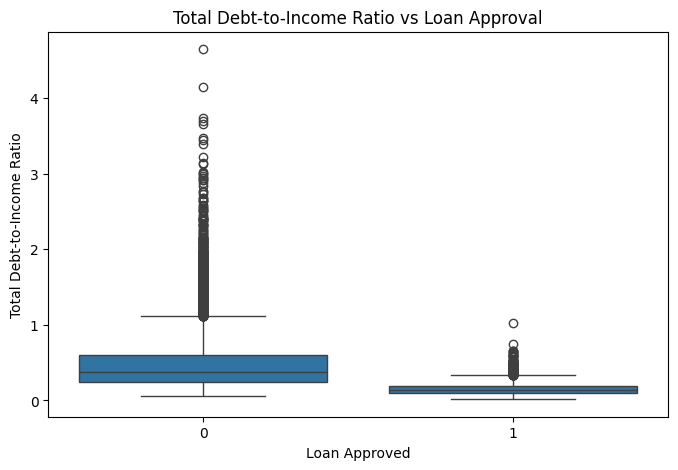

In [11]:
# Total Debt-to-Income Ratio and Loan Approval
plt.figure(figsize=(8,5))

sns.boxplot(
    x='LoanApproved',
    y='TotalDebtToIncomeRatio',
    data=df
)

plt.title('Total Debt-to-Income Ratio vs Loan Approval')
plt.xlabel('Loan Approved')
plt.ylabel('Total Debt-to-Income Ratio')

plt.show()

The boxplot shows a clear difference in Total Debt-to-Income Ratio between approved and denied applicants: the median for approved applicants (~0.14) is far lower than for denied applicants (~0.38). This is consistent with the correlation analysis and the model's feature importance later in this notebook, where `TotalDebtToIncomeRatio` turns out to be the single strongest predictor of loan approval. (Note: this uses `TotalDebtToIncomeRatio` rather than the simpler `DebtToIncomeRatio` column, since the two are redundant - see Data Preparation - and `TotalDebtToIncomeRatio` is the one retained for modeling.)

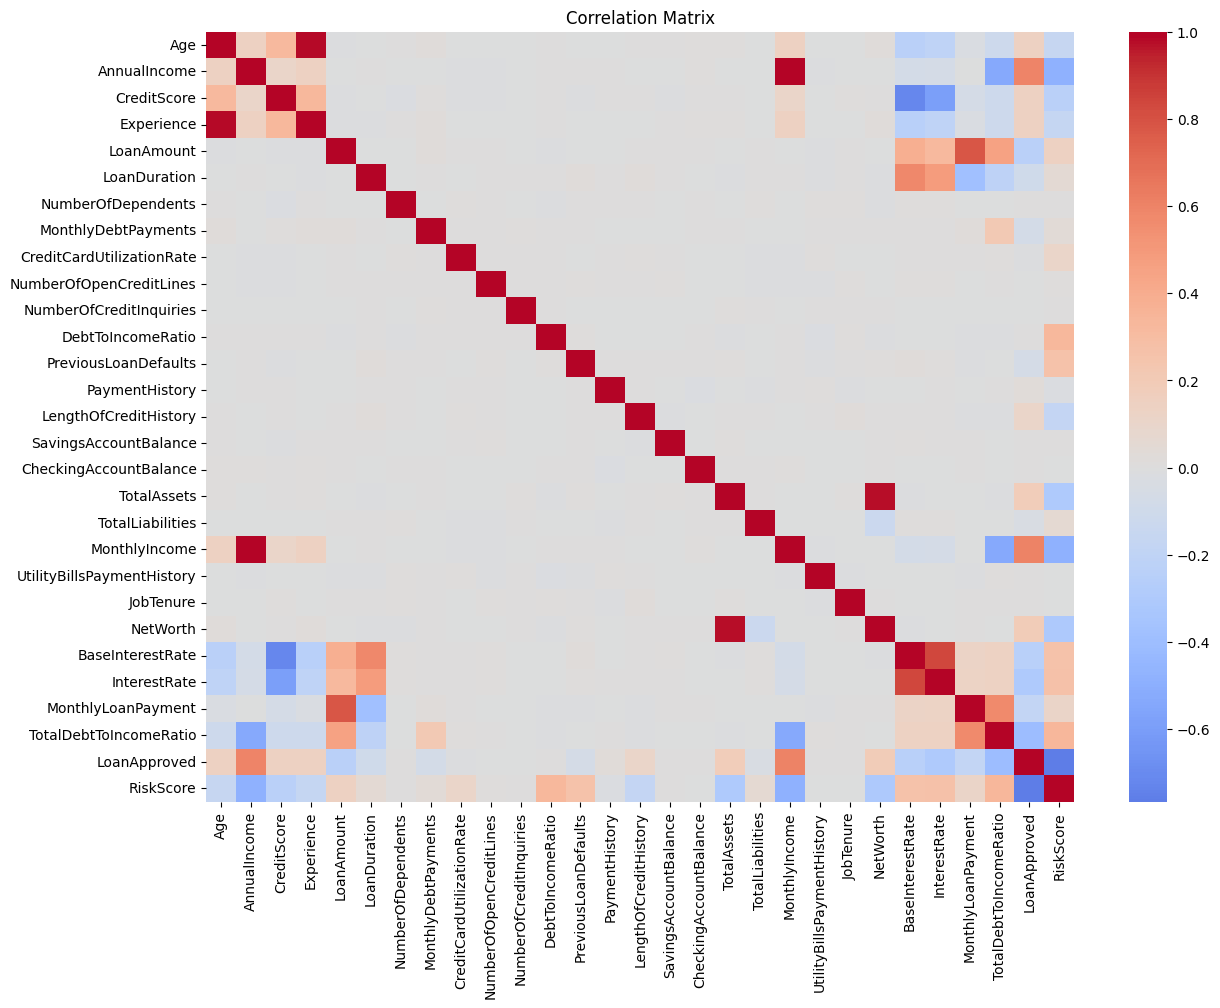

In [12]:
#
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

The correlation heatmap was used to identify relationships among numerical variables. Several variables show noticeable correlations, including AnnualIncome and MonthlyIncome, as well as LoanAmount and MonthlyLoanPayment. LoanApproved appears to be associated with financial indicators such as credit score, income, and debt-related measures. These relationships suggest that multiple financial factors contribute to loan approval decisions.

**Feature engineering opportunities:** a few features could be combined or derived rather than used as-is - e.g. `LoanAmount` relative to `AnnualIncome` (a loan-to-income ratio) could capture affordability more directly than either alone, and `TotalAssets` minus `TotalLiabilities` would reconstruct net worth-style information without reintroducing the dropped `NetWorth` column's redundancy. These are noted as possible future iterations, not implemented in this version to keep the feature set straightforward to interpret.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



**Preprocessing decisions:**
- `RiskScore` is dropped because it correlates at -0.77 with `LoanApproved` - far too strong to be coincidental, and almost certainly used to derive (or derived alongside) the approval decision itself. Including it would be data leakage.
- `Experience`, `MonthlyIncome`, `NetWorth`, `InterestRate`, and `DebtToIncomeRatio` are dropped because each is highly correlated (r > 0.7) with another feature already kept (`Age`, `AnnualIncome`, `TotalAssets`, `BaseInterestRate`, `TotalDebtToIncomeRatio` respectively), so keeping both adds multicollinearity without new signal.
- `EducationLevel` is encoded as **ordinal** (High School < Associate < Bachelor < Master < Doctorate) since it has a genuine order, rather than one-hot encoded.
- Remaining categorical columns are one-hot encoded since they have no inherent order.
- Numeric features are median-imputed then scaled, since Logistic Regression and SVM (used later) are scale-sensitive.

In [13]:
## Target + feature selection
y = df['LoanApproved'].astype(int)

drop_cols = [
    'LoanApproved', 'RiskScore',
    'Experience',
    'MonthlyIncome',
    'NetWorth',
    'InterestRate',
    'DebtToIncomeRatio',
]
X = df.drop(columns=drop_cols)
print("Features used:", X.columns.tolist())
print("Shape:", X.shape)

Features used: ['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'UtilityBillsPaymentHistory', 'JobTenure', 'BaseInterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
Shape: (20000, 28)


In [14]:
# Feature categorization
ordinal_features = ['EducationLevel']
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

nominal_features = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
                     'BankruptcyHistory', 'LoanPurpose']

numeric_features = [c for c in X.columns if c not in ordinal_features + nominal_features]
print("Numeric:", numeric_features)
print("Ordinal:", ordinal_features)
print("Nominal:", nominal_features)

Numeric: ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'UtilityBillsPaymentHistory', 'JobTenure', 'BaseInterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
Ordinal: ['EducationLevel']
Nominal: ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


In [15]:
# Data Prep Code Here - Create New Cells As Needed
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='High School')),
    ('encoder', OrdinalEncoder(categories=[education_order],
                                handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('ord', ordinal_pipe, ordinal_features),
    ('nom', nominal_pipe, nominal_features),
])

In [16]:
# Stratified train/test split - preserves the 76/24 class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class balance:", y_train.value_counts(normalize=True).to_dict())
print("Test class balance:", y_test.value_counts(normalize=True).to_dict())

Train shape: (16000, 28) Test shape: (4000, 28)
Train class balance: {0: 0.761, 1: 0.239}
Test class balance: {0: 0.761, 1: 0.239}


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


**Model choice rationale:** To make sure our evaluation is objective and not biased toward a specific type of algorithm, we selected five classifiers from entirely different machine learning families. This gives us a healthy mix of simple baselines, highly interpretable models, and powerful ensembles:

1.Logistic Regression: Our linear baseline. It’s mathematically straightforward and gives us fully interpretable coefficients to see the direct impact of each feature.

2.Decision Tree: Excellent for capturing non-linear relationships. It breaks decisions down into human-readable rules, which is a massive plus for our compliance and underwriting teams.

3.Random Forest: A bagging ensemble that combines multiple trees. It helps smooth out the noise and reduces the risk of overfitting that you get with a single decision tree.

4.Gradient Boosting: A sequential boosting, It builds trees iteratively to correct past mistakes and usually delivers the strongest raw predictive performance.

5.Support Vector Machine (SVM): A kernel-based approach that is highly effective at finding complex, non-linear decision boundaries once the data is properly scaled.

Dealing with Imbalance: To prevent the models from taking the easy way out and simply guessing the majority class, we are using the class_weight='balanced' parameter (wherever the algorithm supports it). This forces the models to treat the minority $24\%$ class with equal importance during training.

In [17]:
##  Modeling Code Here - Create New Cells as Needed
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
}

results = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression   0.91525   0.765719  0.929916  0.839868  0.979077
4                  SVM   0.91450   0.767422  0.921548  0.837452  0.977299
3    Gradient Boosting   0.92850   0.874720  0.817992  0.845405  0.974396
2        Random Forest   0.89825   0.746188  0.870293  0.803477  0.962588
1        Decision Tree   0.85825   0.649042  0.885983  0.749226  0.917548


**Result:** Gradient Boosting has the best F1 (0.845) and a near-top ROC-AUC (0.974); Logistic Regression edges it out slightly on raw ROC-AUC (0.979) and has far better recall (0.93 vs 0.82) at the cost of precision. **Gradient Boosting is selected for tuning** as the best overall balance, but Logistic Regression remains worth a second look at deployment-time if recall (catching all good applicants) is prioritized over precision.

## Hyperparameter tuning

To squeeze the best performance out of our Gradient Boosting model, we are tuning it using RandomizedSearchCV.

We deliberately chose a randomized search over an exhaustive GridSearchCV to save on computing time. Instead of checking every single combination, it samples a smart, representative spread of the parameter space, giving us a highly optimized model in a fraction of the time.

We are focusing our search on the three parameters that have the biggest impact on the model's bias/variance trade-off:

n_estimators: The total number of sequential trees to build.

learning_rate: How aggressively each new tree corrects the mistakes of the previous one.

max_depth: The complexity and depth of the individual trees, which controls how deeply they can capture feature interactions.

In [18]:
# Cross-validation baseline for Gradient Boosting
pipe = Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))])
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=3)
print("CV ROC-AUC scores:", cv_scores)
print("Mean:", cv_scores.mean())

CV ROC-AUC scores: [0.97464477 0.97254275 0.97215106]
Mean: 0.9731128626373801


In [19]:
# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'clf__n_estimators': [100, 150, 200],
    'clf__learning_rate': [0.05, 0.1, 0.15],
    'clf__max_depth': [2, 3, 4],
}

search = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=6,
                             cv=cv, scoring='roc_auc', n_jobs=3, random_state=42)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

best_model = search.best_estimator_

Best params: {'clf__n_estimators': 200, 'clf__max_depth': 2, 'clf__learning_rate': 0.1}
Best CV ROC-AUC: 0.9760181424361977


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [20]:
# Final test-set evaluation
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("                 Predicted Reject  Predicted Approve")
print(f"Actual Reject         {cm[0,0]:6d}            {cm[0,1]:6d}")
print(f"Actual Approve        {cm[1,0]:6d}            {cm[1,1]:6d}")

Accuracy: 0.9305
Precision: 0.8843537414965986
Recall: 0.8158995815899581
F1: 0.8487486398258978
ROC-AUC: 0.9764163262388731

Confusion Matrix:
                 Predicted Reject  Predicted Approve
Actual Reject           2942               102
Actual Approve           176               780


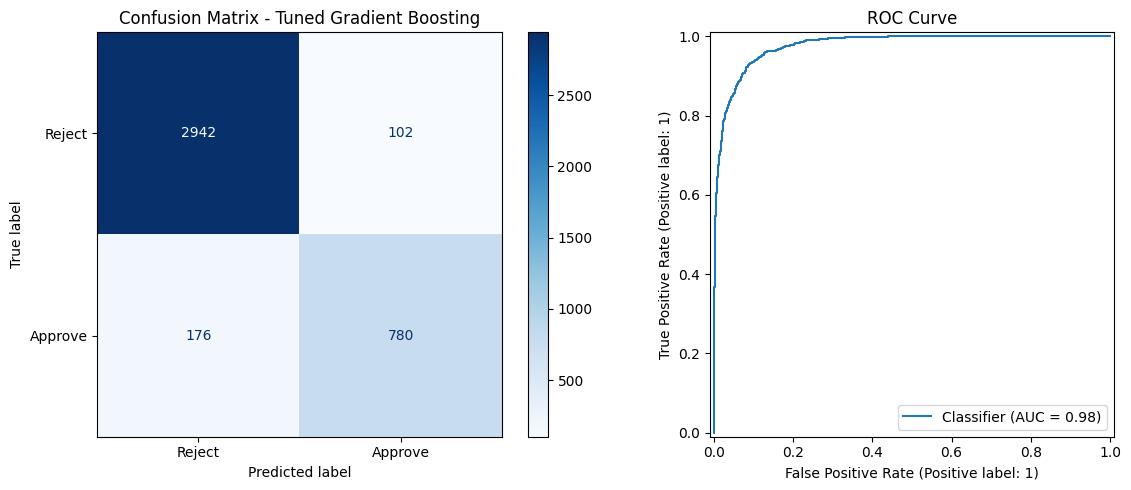

In [21]:
# Visualize: Confusion Matrix and ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Reject', 'Approve']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Tuned Gradient Boosting')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.show()

**Segment performance check:** recall and predicted approval rate are broken down by `EmploymentStatus`, `EducationLevel`, and `HomeOwnershipStatus` (note: these are the raw pre-one-hot-encoded values from `X_test`, used here only for grouping, not fed into the model in this form). This is a first-pass fairness check - if recall or approval rate diverges sharply across groups with otherwise similar financial profiles, that's a signal for a deeper fair-lending review before deployment.

In [22]:
# Performance across data segments (fair-lending / bias check)
segment_cols = ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus']

for col in segment_cols:
    print(f"\n=== Recall and approval rate by {col} ===")
    seg_df = X_test.copy()
    seg_df['actual'] = y_test.values
    seg_df['pred'] = y_pred
    summary = seg_df.groupby(col).apply(
        lambda g: pd.Series({
            'n': len(g),
            'actual_approval_rate': g['actual'].mean(),
            'predicted_approval_rate': g['pred'].mean(),
            'recall': (g.loc[g['actual'] == 1, 'pred'] == 1).mean() if (g['actual'] == 1).any() else float('nan')
        })
    )
    print(summary)



=== Recall and approval rate by EmploymentStatus ===
                       n  actual_approval_rate  predicted_approval_rate  \
EmploymentStatus                                                          
Employed          3402.0              0.242210                 0.223398   
Self-Employed      311.0              0.263666                 0.221865   
Unemployed         287.0              0.174216                 0.184669   

                    recall  
EmploymentStatus            
Employed          0.817961  
Self-Employed     0.756098  
Unemployed        0.880000  

=== Recall and approval rate by EducationLevel ===
                     n  actual_approval_rate  predicted_approval_rate  \
EducationLevel                                                          
Associate        782.0              0.207161                 0.181586   
Bachelor        1163.0              0.279450                 0.263972   
Doctorate        156.0              0.442308                 0.416667   
High Sch

In [23]:
# Custom cost-weighted metric
avg_loan = X_test['LoanAmount'].mean()
fp = cm[0, 1]
fn = cm[1, 0]

default_rate_assumed = 0.15
avg_interest_rate = 0.10

cost_fp = fp * avg_loan * default_rate_assumed
lost_revenue_fn = fn * avg_loan * avg_interest_rate
total_cost = cost_fp + lost_revenue_fn

print(f"False approvals (FP): {fp}, estimated default exposure: ${cost_fp:,.0f}")
print(f"False rejections (FN): {fn}, estimated lost interest revenue: ${lost_revenue_fn:,.0f}")
print(f"Total estimated cost: ${total_cost:,.0f}")

False approvals (FP): 102, estimated default exposure: $379,525
False rejections (FN): 176, estimated lost interest revenue: $436,578
Total estimated cost: $816,103


                    feature  importance
     TotalDebtToIncomeRatio    0.580592
               AnnualIncome    0.168233
                TotalAssets    0.064610
               LoanDuration    0.055164
           BaseInterestRate    0.052271
      LengthOfCreditHistory    0.020145
             EducationLevel    0.019186
                 LoanAmount    0.008365
       PreviousLoanDefaults    0.008098
      BankruptcyHistory_Yes    0.006965
                        Age    0.003485
       BankruptcyHistory_No    0.003278
         MonthlyLoanPayment    0.002703
EmploymentStatus_Unemployed    0.002243
           TotalLiabilities    0.001726


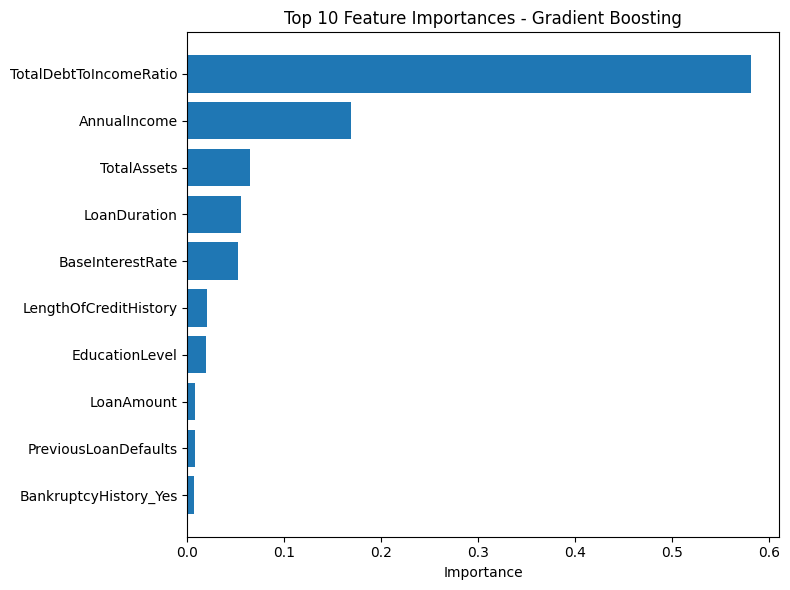

In [24]:
# Feature importance
nominal_encoder = best_model.named_steps['prep'].named_transformers_['nom'].named_steps['encoder']
nominal_names = list(nominal_encoder.get_feature_names_out(nominal_features))

feature_names = numeric_features + ordinal_features + nominal_names
importances = best_model.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False)

print(imp_df.head(15).to_string(index=False))

plt.figure(figsize=(8, 6))
plt.barh(imp_df.head(10)['feature'][::-1], imp_df.head(10)['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.tight_layout()
plt.show()

### Business Recommendations and Limitations

**Key findings:**

The Dominance of DTI: TotalDebtToIncomeRatio absolutely drives the model's decisions, accounting for 58% of the total feature importance. This means it carries far more weight than an applicant's credit score or payment history. We should sync with the Risk team to see if this single-factor heavy bias matches their intentional lending policy, or if we need to diversify our feature mix. Relying too heavily on a single ratio risks auto-rejecting otherwise great applicants who just happen to have a temporarily high DTI (like someone who recently bought a home).

Secondary Drivers: AnnualIncome, TotalAssets, LoanDuration, and BaseInterestRate serve as secondary but still meaningful drivers in the decision-making process.

Performance vs. Baseline: The model drastically outperforms a naive baseline (which lazily defaults to a 76% accuracy but scores a 0% recall). Given the sharp class imbalance we are dealing with, our model is proving it can actually catch the nuanced risks rather than just guessing the majority class.

**Limitations:**

Sanity-Checking the Custom Cost Metric: The dollar figures in our custom cost metric are built on illustrative default and interest rate assumptions. Before anyone uses these estimates for actual budgeting or deployment decisions, we need to swap those out with FinTech’s real historical data.

The Next Phase for RiskScore: We deliberately kept RiskScore out of the feature mix to avoid data leakage. That said, it is still a prime candidate for a follow-up regression model. Once a loan is approved, we can use that secondary model to drive risk-based interest pricing.

Investigating the Education Data Anomaly: We noticed a strange pattern where every single applicant with a missing EducationLevel was rejected. This feels like an upstream operational artifact or a data pipeline glitch rather than a natural lending pattern. We should sync with the ops team to find out what's happening at the source instead of just guessing.

Fair-Lending and Bias Audits: Right now, we haven't broken down the model's performance across demographic or segment slices (like EmploymentStatus or EducationLevel). Given the compliance and fair-lending concerns we flagged at the start, running a formal fairness and bias audit across these segments is an absolute must before this goes anywhere near production.


**Recommended next step:**

Human-in-the-Loop Implementation: Deploy the model strictly as a decision-support tool for our underwriting team rather than handing over full automation. This keeps our human experts in control while speeding up their workflow.

Automated Compliance Guardrails: Pair the system with documented adverse-action reasons pulled directly from the model's feature importance. This gives underwriters an instant, clear explanation for rejections, making compliance reporting painless.

Financial Reality Check: Before flipping the switch, we need to sync with the finance team to swap out our placeholder assumptions with FinTech's real historical default and interest rates. This will ensure our cost-benefit metrics are perfectly accurate before deployment.